In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('Zomato Dataset.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [5]:
df.describe(include='all')

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
count,45584,45584,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584,43853,45584,44968,44983,45584.000000,45584,45584,44591.000000,45356,44384,45584.000000
unique,45584,1320,NaN,NaN,NaN,NaN,NaN,NaN,44,176,193,6,4,NaN,4,4,NaN,2,3,NaN
top,0xcdcd,JAPRES11DEL02,NaN,NaN,NaN,NaN,NaN,NaN,15-03-2022,21:55,21:30,Fog,Low,NaN,Snack,motorcycle,NaN,No,Metropolitian,NaN
freq,1,67,NaN,NaN,NaN,NaN,NaN,NaN,1192,461,495,7653,15476,NaN,11530,26429,NaN,44460,34087,NaN
mean,NaN,NaN,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,NaN,NaN,NaN,NaN,NaN,1.023385,NaN,NaN,0.744635,NaN,NaN,26.293963
std,NaN,NaN,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,NaN,NaN,NaN,NaN,NaN,0.839055,NaN,NaN,0.572510,NaN,NaN,9.384298
min,NaN,NaN,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,10.000000
25%,NaN,NaN,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,19.000000
50%,NaN,NaN,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,26.000000
75%,NaN,NaN,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,1.000000,NaN,NaN,32.000000


In [6]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

In [7]:
# Numerical columns → median
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → mode
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Festival', 'City']
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Time column → forward fill
df['Time_Orderd'] = df['Time_Orderd'].fillna(method='ffill')

C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\2217710037.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Time_Orderd'] = df['Time_Orderd'].fillna(method='ffill')


In [8]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(',','_')
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_orderd',
       'time_order_picked', 'weather_conditions', 'road_traffic_density',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city', 'time_taken (min)'],
      dtype='object')

The columns readable and consistent


In [10]:
df = df.rename(columns={ 'time_taken (min)':'total_minutes'})
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_orderd',
       'time_order_picked', 'weather_conditions', 'road_traffic_density',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city', 'total_minutes'],
      dtype='object')

In [11]:
labels = ['young','adult','middle_aged','senior']

df['age_level'] = pd.qcut(df['delivery_person_age'], q=4, labels=labels)

df[['age_level','delivery_person_age']].head(10)

,age_level,delivery_person_age
0,senior,36.0
1,young,21.0
2,young,23.0
3,middle_aged,34.0
4,young,24.0
5,adult,29.0
6,senior,35.0
7,middle_aged,33.0
8,middle_aged,34.0
9,young,21.0


The delivery person

In [12]:
print((df['age_level'] == 'young').sum())

12991


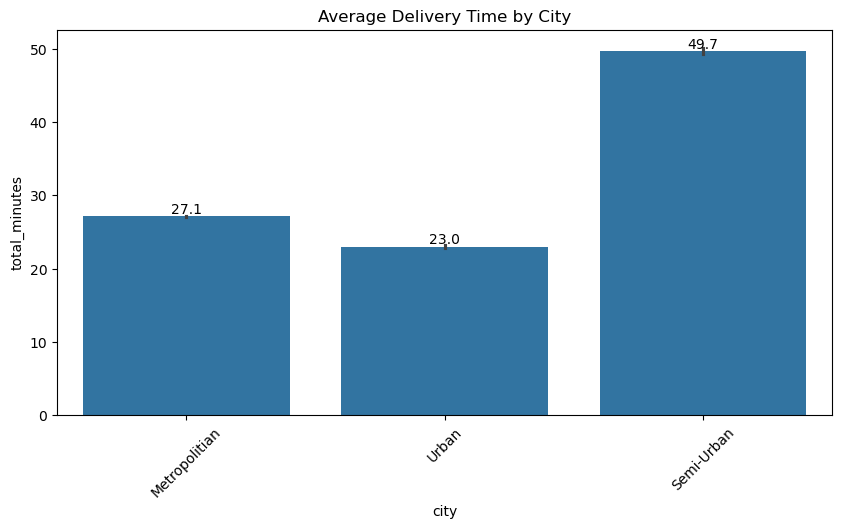

In [13]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='city', y='total_minutes', data=df, estimator='mean')
plt.xticks(rotation=45)
plt.title("Average Delivery Time by City")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()


This chart shows the average delivery time for each city.

The tallest bar means that city takes the longest time.

The shortest bar means that city is the fastest.

The numbers above each bar give the exact average minutes, making it easy to compare cities directly.

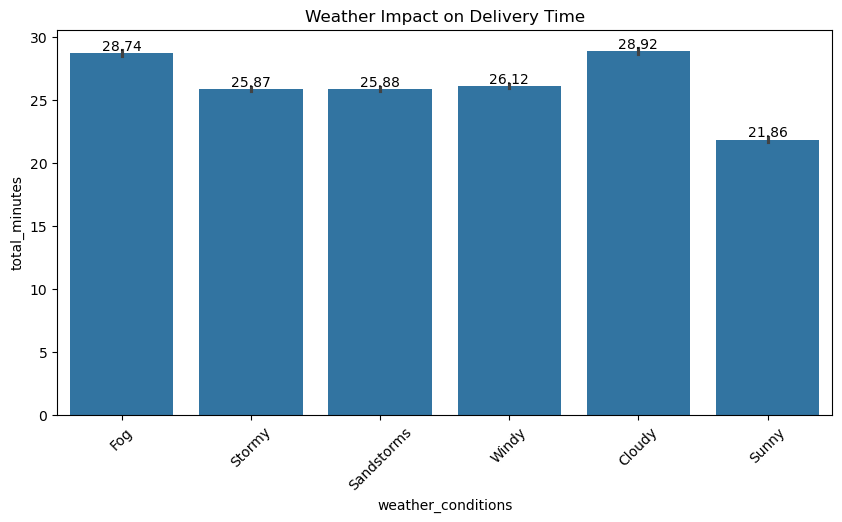

In [14]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x='weather_conditions', y='total_minutes', data=df, estimator='mean')
plt.title("Weather Impact on Delivery Time")
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

This chart shows how different weather conditions affect average delivery time.

Bars that are taller mean deliveries take longer under those weather conditions.

Shorter bars mean deliveries are faster.

For example, rainy or foggy weather usually increases delivery time, while clear weather allows quicker deliveries.

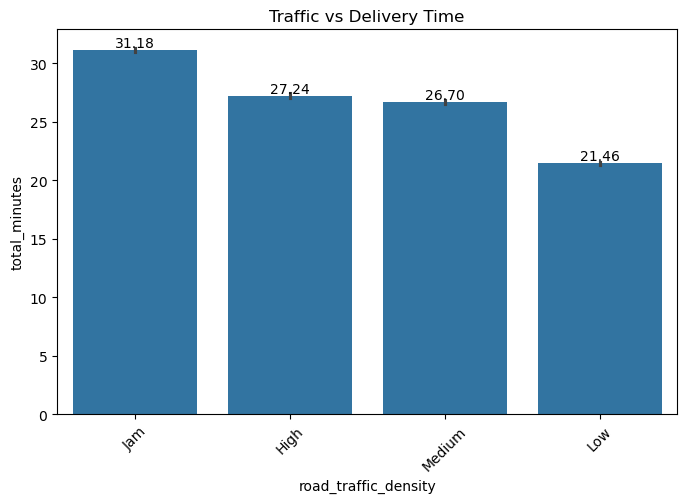

In [15]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='road_traffic_density', y='total_minutes', data=df, estimator='mean')
plt.title("Traffic vs Delivery Time")

# Add labels above each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()


The chart shows how traffic density affects delivery speed.

Heavier traffic leads to longer delivery times (taller bars).

Lighter traffic results in faster deliveries (shorter bars).

The labels above each bar give the exact average minutes, making comparison easy.

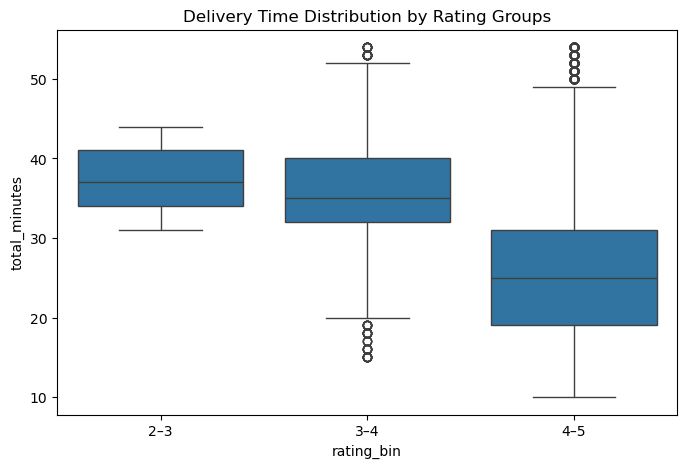

In [16]:
df['rating_bin'] = pd.cut(df['delivery_person_ratings'], bins=[2,3,4,5], labels=['2–3','3–4','4–5'])
plt.figure(figsize=(8,5))
sns.boxplot(x='rating_bin', y='total_minutes', data=df)
plt.title("Delivery Time Distribution by Rating Groups")
plt.show()


In [17]:
Q1 = df['delivery_person_ratings'].quantile(0.25)
Q3 = df['delivery_person_ratings'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['delivery_person_ratings'] < lower_bound) | (df['delivery_person_ratings'] > upper_bound)]
print(outliers)


           id delivery_person_id  delivery_person_age  \
0      0xcdcd      DEHRES17DEL01                 36.0   
6      0x3aab      MYSRES01DEL01                 35.0   
7      0x689b     PUNERES20DEL01                 33.0   
10     0x36b8     PUNERES19DEL02                 25.0   
14     0x539b      MUMRES02DEL01                 25.0   
...       ...                ...                  ...   
45550  0xa810     BANGRES07DEL02                 24.0   
45552  0xb55b      JAPRES13DEL03                 27.0   
45567  0x2bed   RANCHIRES02DEL02                 34.0   
45576  0xc9ab      KNPRES03DEL01                 30.0   
45578  0x1178   RANCHIRES16DEL01                 35.0   

       delivery_person_ratings  restaurant_latitude  restaurant_longitude  \
0                          4.2            30.327968             78.046106   
6                          4.0            12.311072             76.654878   
7                          4.2            18.592718             73.773572   
10     

Q1 = 25th percentile of ratings

Q3 = 75th percentile of ratings

IQR = spread between Q3 and Q1

Bounds = anything below lower_bound or above upper_bound is flagged as an outlier

outliers now contains all rows where ratings are unusually low or high.

In [18]:
df['is_outlier'] = (df['delivery_person_ratings'] < lower_bound) | (df['delivery_person_ratings'] > upper_bound)


It compares each rating against the IQR-based boundaries (lower_bound and upper_bound).

If a rating is below the lower bound or above the upper bound → True (outlier).

Otherwise → False (normal value).

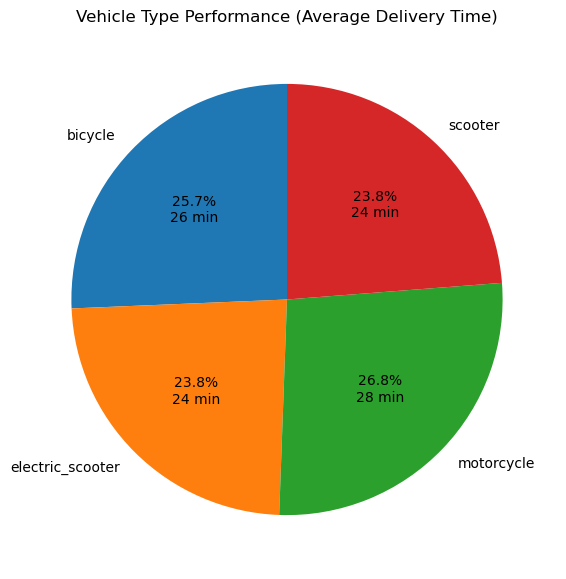

In [19]:
# Calculate average delivery time per vehicle type
vehicle_avg = df.groupby('type_of_vehicle')['total_minutes'].mean()

# Custom label function
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n{absolute} min"

# Plot pie chart with labels
plt.figure(figsize=(7,7))
plt.pie(vehicle_avg, labels=vehicle_avg.index, autopct=lambda pct: func(pct, vehicle_avg), startangle=90)
plt.title("Vehicle Type Performance (Average Delivery Time)")
plt.show()

In [20]:
import pandas
import sqlalchemy
import psycopg2

In [21]:
df['total_orders'] =df.groupby('type_of_order')['type_of_order'].transform('count')

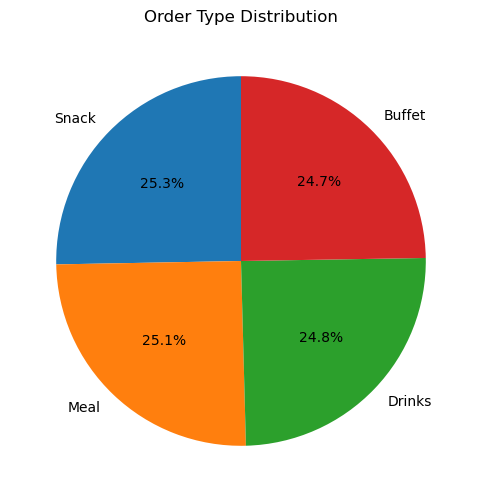

In [22]:
# count each order type
summary = df['type_of_order'].value_counts()

# create pie chart
plt.figure(figsize=(6,6))
plt.pie(summary, labels=summary.index, autopct='%1.1f%%', startangle=90)

plt.title('Order Type Distribution')
plt.show()

C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\4043254573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\4043254573.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='weather conditions')


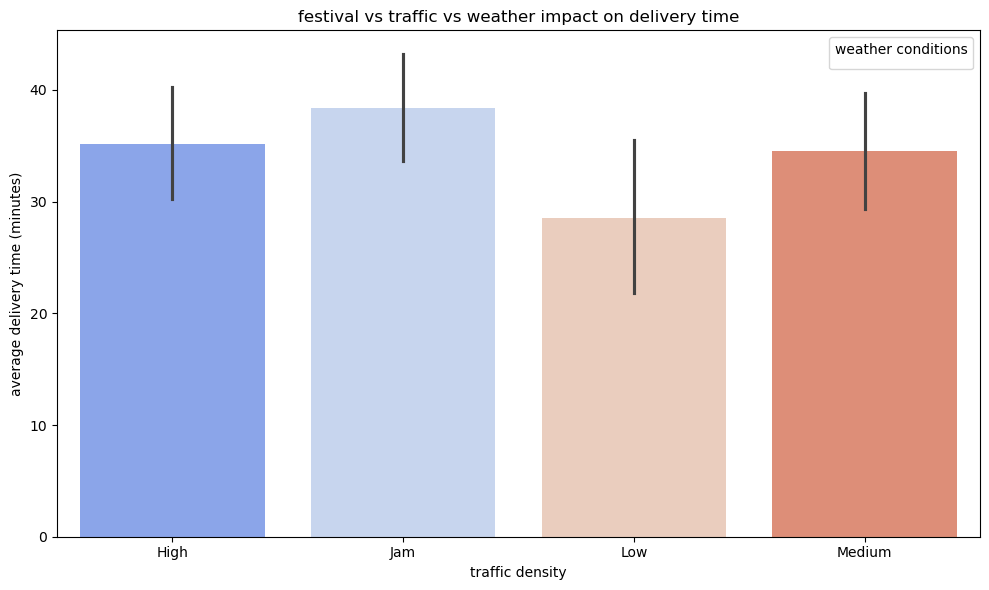

In [23]:
grouped = df.groupby(['festival','road_traffic_density','weather_conditions'])['total_minutes'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=grouped,
    x='road_traffic_density',
    y='total_minutes',
    palette='coolwarm'
)

plt.title('festival vs traffic vs weather impact on delivery time')
plt.xlabel('traffic density')
plt.ylabel('average delivery time (minutes)')
plt.legend(title='weather conditions')

# separate plots for festival vs non-festival
plt.tight_layout()
plt.show()

Fastest deliveries: low traffic, sunny weather, non‑festival.

Slower deliveries: medium/high traffic, especially in festivals.

Rainy or stormy weather adds more delay.

Longest delays: festival + high traffic + bad weather.

The order almost same distribution shown by pie chart

<Figure size 1000x600 with 0 Axes>

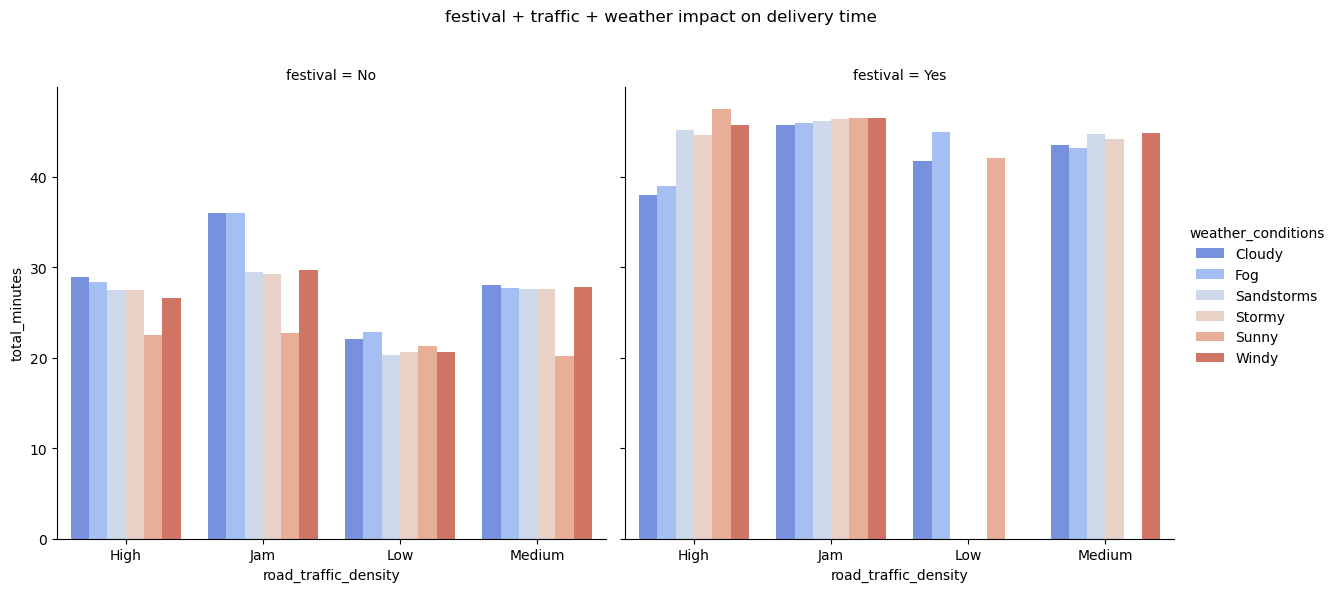

In [24]:
festival_weather = df.groupby(['festival','road_traffic_density','weather_conditions'])['total_minutes'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.catplot(
    data=festival_weather,
    x='road_traffic_density',
    y='total_minutes',
    hue='weather_conditions',
    col='festival',
    kind='bar',
    palette='coolwarm',
    height=6,
    aspect=1
)

plt.subplots_adjust(top=0.85)
plt.suptitle('festival + traffic + weather impact on delivery time')
plt.show()

Fastest: low traffic, sunny, non‑festival.

Slower: medium/high traffic, festivals.

Worse: rainy/stormy weather.

Longest: festival + high traffic + bad weather.

C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\2804475021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='festival', y='total_minutes', palette='coolwarm')


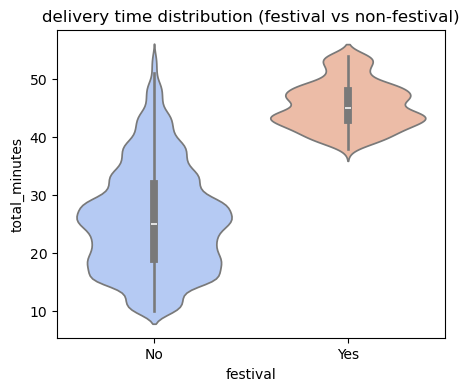

In [25]:
plt.figure(figsize=(5,4))
sns.violinplot(data=df, x='festival', y='total_minutes', palette='coolwarm')
plt.title('delivery time distribution (festival vs non-festival)')
plt.show()

Festival deliveries are slower and more spread out.
Non‑festival deliveries are faster and steadier.
Festivals cause delays; normal days are quicker.

C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\1973880739.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(data=df, x='multiple_deliveries', y='total_minutes',
C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\1973880739.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=df, x='multiple_deliveries', y='total_minutes',


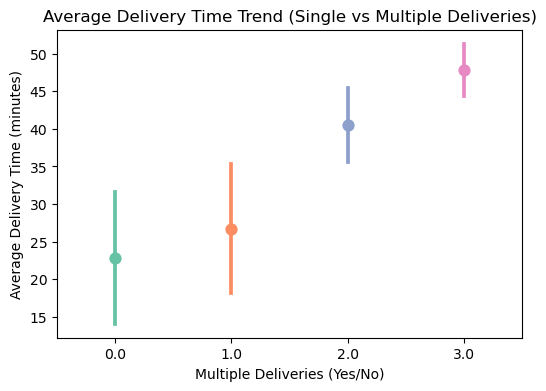

In [26]:
plt.figure(figsize=(6,4))
sns.pointplot(data=df, x='multiple_deliveries', y='total_minutes',
              palette='Set2', ci='sd', markers='o', linestyles='-')

plt.title('Average Delivery Time Trend (Single vs Multiple Deliveries)')
plt.xlabel('Multiple Deliveries (Yes/No)')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

Efficiency drops when delivery personnel manage multiple orders at once.


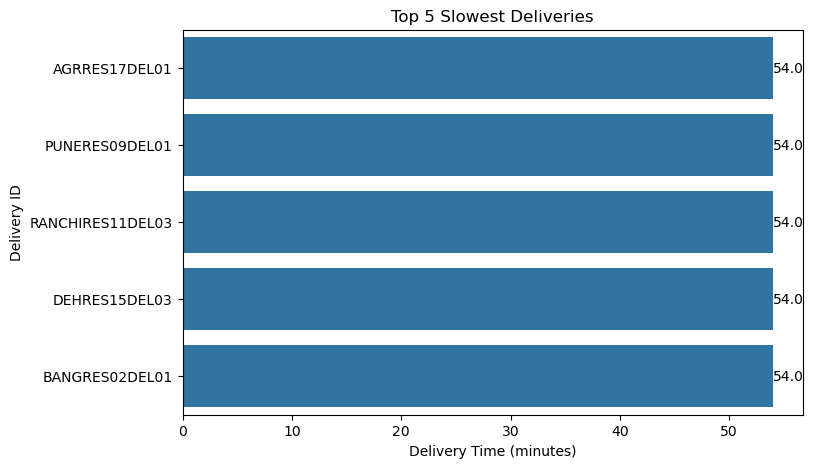

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
df_top5 = df.sort_values(by="total_minutes", ascending=False).head(5)
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df_top5, y='delivery_person_id', x='total_minutes')

plt.title('Top 5 Slowest Deliveries')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Delivery ID')

# Add labels at the end of bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}",
                (p.get_x() + p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center')

plt.show()


Shows the five longest delivery times.

The tallest bar = slowest delivery overall.

These are clear outliers compared to typical times.

C:\Users\Iman bohare\AppData\Local\Temp\ipykernel_21396\3975095392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


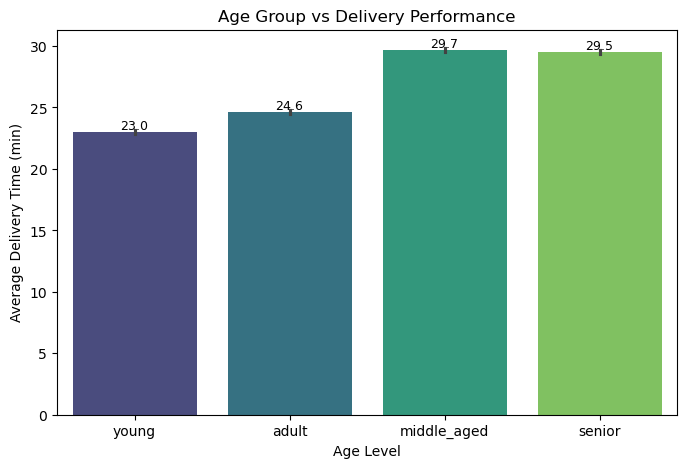

In [28]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x='age_level',
    y='total_minutes',
    palette='viridis'
)

# add value labels on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Age Group vs Delivery Performance')
plt.xlabel('Age Level')
plt.ylabel('Average Delivery Time (min)')

plt.show()

In [29]:
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'order_date', 'time_orderd',
       'time_order_picked', 'weather_conditions', 'road_traffic_density',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city', 'total_minutes', 'age_level',
       'rating_bin', 'is_outlier', 'total_orders'],
      dtype='object')

In [30]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "Netbeans" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "Zomato"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "zomatotable"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'zomatotable' in database 'Zomato'.
